This third notebook reshapes our data from a 2d data frame to a 3d data frame ready for LZIFU use

Similar to the last two notebooks, changing the first cell is all that is required for it to run correctly

In [2]:
#These are the python packages that are needed for the full code. If you get an error, that means some package
#must be installed on python

from astropy.io import fits
import astropy
import matplotlib.pyplot as plt
import numpy as np
import datetime
import glob
from scipy.optimize import curve_fit
from numpy import loadtxt
from matplotlib.backends.backend_pdf import PdfPages
from astropy import units as u
from astropy.io.fits import Header
import os
import astropy.stats as ap
from astropy.io import fits
from astropy.modeling import models, fitting
from astropy.modeling.models import custom_model
from astropy.modeling import Fittable1DModel, Parameter
import pandas as pd
import matplotlib.pyplot as plt
from scipy import interpolate
import numpy as np
import math
import numpy.polynomial.polynomial as poly
import extinction
import fnmatch

In [3]:
#In this cell, we will be changing the inputs required throughout the rest of the pipeline
path = "/Users/spogs/Documents/TypeIt_Data_Reduction_Pipeline/"#This is the file path to the main reduction
galaxy_name = "J0800+3743_major" #Using our observing logs, this is the galaxy's name that we want to reduce
galaxy_name_2 = "J0800+3743"
galaxy_file_name = galaxy_name #Same as last line (Artifact of a past code that needed 2)
standard_star_name = "HR3454" #Standard star name (Also observed right before/after our galaxy)
date = "2-16" #observation date as a number
date_link = "Feb 16 2020" # observation date
RA = 120.1986 #galaxy's RA value from SPOGs catalog
Dec = 37.7287 #galaxy's Dec value from SPOGs catalog
setting = "A" #Should be an A or B. This refers to the wavelength range observed.
#The observing logs should indicate which
#Using observing logs, this is the file numbers for the bias calibration frames that we took
bias_files = [16, 17, 18, 19,20, 21, 22, 23, 24, 25]
#Using observing logs, this is the file numbers for the dome flat calibration frames that we took
dome_flat_files = [26, 27, 28, 29, 30]
#Using observing logs, this is the file numbers for the arc calibration frames that we took
arc_files = [11, 12, 13, 14, 15]
#Using observing logs, this is the file numbers for the galaxy files
galaxy_files = [37,38,39,40]
number_of_galaxy_files = len(galaxy_files)
galaxy_exposure_times = [900, 900, 900,900]
#Using observing logs, this is the file numbers for the star files
star_files = [35,36]
number_of_star_files = len(star_files)
star_exposure_times = [1, 1]
literature_standard_star_values = "HR3454.txt"
target_row = 141
target_row_script = "141"

In [4]:
#Change file path when needed
file = fits.open(path + "Flux Calibrated SPOGs/" + galaxy_name + "_Flux_Calibrated.fits")
file.info()

Filename: /Users/spogs/Documents/TypeIt_Data_Reduction_Pipeline/Flux Calibrated SPOGs/J0800+3743_major_Flux_Calibrated.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  DATA          1 PrimaryHDU      19   (2042, 282)   float64   
  1                1 ImageHDU         7   (2042, 282)   float64   


In [5]:
data = file[0].data
error = file[1].data

flipped = data
flippederror = error

In [20]:
base_data = flipped *10.0**20
base_error = flippederror * 10**40

plt.figure(figsize=(15,5))
rowu_slice = np.resize(base_error[target_row-1:target_row,:], 2042)
plt.plot(rowu_slice)
plt.title("Row " + target_row_script + " Error 3D Cube " + galaxy_name + ";  " + date)
plt.xlabel("Column Number")
plt.ylabel("Error " + galaxy_name + " (var.)")
if not os.path.exists(path + "Working Files/Error Propagation/3D Cube/"):
        os.makedirs(path + "Working Files/Error Propagation/3D Cube/")
plt.savefig(path + "Working Files/Error Propagation/3D Cube/Error 3D Cube " + standard_star_name + " Slice Row "+target_row_script+".jpg",bbox_inches='tight')
plt.close()

base_data =base_data.astype(np.float32)
base_error = base_error.astype(np.float32)

transposed = np.transpose(base_data)
transposed_error = np.transpose(base_error)

reshaped_data = transposed.reshape(base_data.shape[1], base_data.shape[0],1 ) 
reshaped_data = reshaped_data.astype(np.float32)
double = np.repeat(reshaped_data,2,-1)

reshaped_error = transposed_error.reshape(base_error.shape[1], base_error.shape[0],1 ) 
reshaped_error = reshaped_error.astype(np.float32)
reshaped_error [reshaped_error <= 0] = .000000001
double_error = np.repeat(reshaped_error,2,-1)

In [22]:
#bad pixel map
bad_pixel_map = double_error * 0

In [26]:
empty_hdu = fits.Header()
empty_primary = fits.PrimaryHDU(header=empty_hdu)

spectrum_hdu = fits.ImageHDU(double)
error_hdu = fits.ImageHDU(double_error)
bpm_hdu = fits.ImageHDU(bad_pixel_map)

data_cube = fits.HDUList([empty_primary,spectrum_hdu,error_hdu,bpm_hdu])

print(data_cube[1].shape)

#Change file path when needed
if not os.path.exists(path + "Working Files/Temp Cubes/"):
        os.makedirs(path + "Working Files/Temp Cubes/")
data_cube.writeto(path + "Working Files/Temp Cubes/Temp_Cube_" + galaxy_name +".fits",overwrite=True)

(2042, 282, 2)


In [28]:
#Change file path when needed
cube = fits.open(path + "Working Files/Temp Cubes/Temp_Cube_" + galaxy_name +".fits")
cube.info()
cube[1].shape

Filename: /Users/spogs/Documents/TypeIt_Data_Reduction_Pipeline/Working Files/Temp Cubes/Temp_Cube_J0800+3743_major.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 ImageHDU         8   (2, 282, 2042)   float32   
  2                1 ImageHDU         8   (2, 282, 2042)   float32   
  3                1 ImageHDU         8   (2, 282, 2042)   float32   


(2042, 282, 2)

In [30]:
pixel = np.loadtxt(path + 'Observations/Wav_'+ date +'-2_' + setting + '.txt', comments="#",delimiter="	")
x = pixel[:,1]
y = pixel[:,0]
p = np.polyfit(x, y, 1)

In [32]:
print(p)

[-1.33812451e+00  7.27014291e+03]


In [34]:
galaxy_cont = data

Text(0, 0.5, 'Flux')

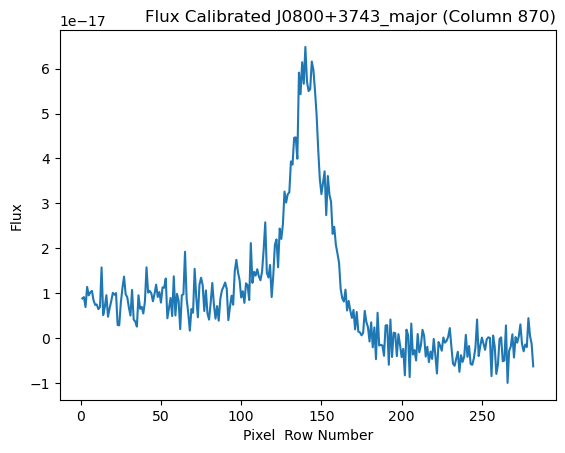

In [36]:
x_line_fit = np.linspace(1,282,282)
y_line_fit = galaxy_cont[:,870:871]
y_line_fit = y_line_fit.reshape(-2)
plt.plot(x_line_fit,y_line_fit)
plt.title("Flux Calibrated " + galaxy_name + " (Column 870)" ,color="black", loc='right')
plt.xlabel('Pixel  Row Number')
plt.ylabel('Flux')

In [38]:
maxium = max(y_line_fit)
index_max = max(range(len(y_line_fit)), key=y_line_fit.__getitem__)

#Attempt to fit a gaussian to 1 emission line on master arc frame
compound_model_bounded = models.Gaussian1D(maxium, 141, 15) + models.Polynomial1D(degree=1) #3-17 is y axis. change if the y axis is a different scale
delta = 15
compound_model_bounded.mean_0.max = 141 + delta #guess to change, the 140 is the "center"
compound_model_bounded.mean_0.min = 141 - delta

fitter = fitting.LevMarLSQFitter()
compound_fit_bounded = fitter(compound_model_bounded, x_line_fit,y_line_fit)

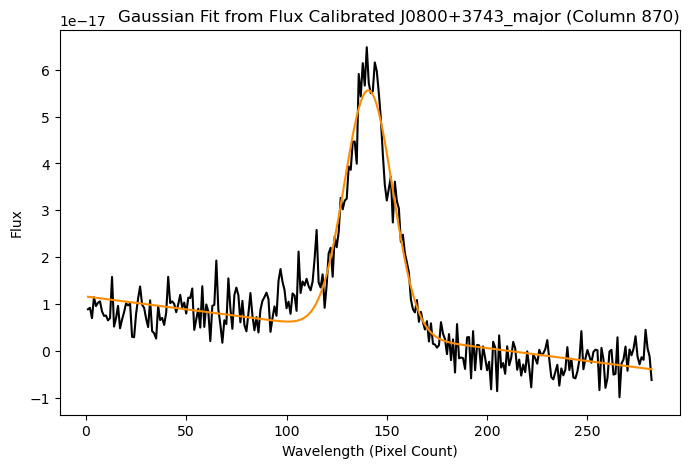

In [40]:
plt.figure(figsize=(8,5))
plt.plot(x_line_fit,y_line_fit, color='k')
plt.plot(x_line_fit, compound_fit_bounded(x_line_fit), color='darkorange')
plt.title("Gaussian Fit from Flux Calibrated " + galaxy_name + " (Column 870)" ,color="black", loc='right')
plt.xlabel('Wavelength (Pixel Count)')
plt.ylabel('Flux')
plt.show()

In [42]:
print(compound_fit_bounded.parameters[1])
print(round(compound_fit_bounded.parameters[1],0))

140.89695271399208
141.0


In [44]:
test0 = cube[0].header
test0.set('OBJECT', galaxy_name + ' (DATA)')
test0.set('BUNIT','10**(20)*erg/s/cm**2/Angstrom')
test0.set('CRPIX1',round(compound_fit_bounded.parameters[1],0))
test0['CRPIX1'] = (round(compound_fit_bounded.parameters[1],0),'Center of galaxy')
test0.set('CRPIX2',round(compound_fit_bounded.parameters[1],0))
test0['CRPIX2'] = (round(compound_fit_bounded.parameters[1],0),'Center of galaxy')
test0.set('CUNIT1','deg     ')
test0.set('CUNIT2','deg     ')
test0.set('CTYPE1','RA---TAN')
test0.set('CTYPE2','DEC--TAN')
test0.set('CRVAL1',RA)
test0.set('CDELT1',-9.4444444*10**(-5))
test0['CDELT1'] = (-9.4444444*10**(-5),'Spatial scale in degrees per pixel')
test0.set('CRVAL2',Dec)
test0.set('CDELT2 ', 9.4444444*10**(-5))
test0['CDELT2'] = (9.4444444*10**(-5),'Spatial scale in degrees per pixel')
test0.set('CTYPE3','AWAV    ')
test0.set('CUNIT3','Angstrom')
test0.set('CRPIX3',1.)
test0.set('CRVAL3', np.polyval([p[0],p[1]],2041))
test0['CRVAL3'] = (np.polyval([p[0],p[1]],2041),'Starting wavelength value')
test0.set('CDELT3',round(np.abs(p[0]),8))
test0['CDELT3'] = (round(np.abs(p[0]),8),'Wavelength scale in Angstrom per pixel')
print(repr(test0))

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T                                                  
OBJECT  = 'J0800+3743_major (DATA)'                                             
BUNIT   = '10**(20)*erg/s/cm**2/Angstrom'                                       
CRPIX1  =                141.0 / Center of galaxy                               
CRPIX2  =                141.0 / Center of galaxy                               
CUNIT1  = 'deg     '                                                            
CUNIT2  = 'deg     '                                                            
CTYPE1  = 'RA---TAN'                                                            
CTYPE2  = 'DEC--TAN'                                                            
CRVAL1  =             120.19

In [46]:
test = cube[0].header
test.set('EXTNAME','DATA  ')

In [48]:
test2 = cube[1].header
test2.set('EXTNAME','ERROR  ')

test2.set('BUNIT','10**(20)*erg/s/cm**2/Angstrom')
test2.set('CRPIX1',round(compound_fit_bounded.parameters[1],0))
test2['CRPIX1'] = (round(compound_fit_bounded.parameters[1],0),'Center of galaxy')
test2.set('CRPIX2',round(compound_fit_bounded.parameters[1],0))
test2['CRPIX2'] = (round(compound_fit_bounded.parameters[1],0),'Center of galaxy')
test2.set('CUNIT1','deg     ')
test2.set('CUNIT2','deg     ')
test2.set('CTYPE1','RA---TAN')
test2.set('CTYPE2','DEC--TAN')
test2.set('CRVAL1',RA)
test2.set('CDELT1',-9.4444444*10**(-5))
test2['CDELT1'] = (-9.4444444*10**(-5),'Spatial scale in degrees per pixel')
test2.set('CRVAL2',Dec)
test2.set('CDELT2 ', 9.4444444*10**(-5))
test2['CDELT2'] = (9.4444444*10**(-5),'Spatial scale in degrees per pixel')
test2.set('CTYPE3','AWAV    ')
test2.set('CUNIT3','Angstrom')
test2.set('CRPIX3',1.)
test2.set('CRVAL3', np.polyval([p[0],p[1]],2041))
test2['CRVAL3'] = (np.polyval([p[0],p[1]],2041),'Starting wavelength value')
test2.set('CDELT3',round(np.abs(p[0]),8))
test2['CDELT3'] = (round(np.abs(p[0]),8),'Wavelength scale in Angstrom per pixel')
print(repr(test2))

XTENSION= 'IMAGE   '           / Image extension                                
BITPIX  =                  -32 / array data type                                
NAXIS   =                    3 / number of array dimensions                     
NAXIS1  =                    2                                                  
NAXIS2  =                  282                                                  
NAXIS3  =                 2042                                                  
PCOUNT  =                    0 / number of parameters                           
GCOUNT  =                    1 / number of groups                               
EXTNAME = 'ERROR   '                                                            
BUNIT   = '10**(20)*erg/s/cm**2/Angstrom'                                       
CRPIX1  =                141.0 / Center of galaxy                               
CRPIX2  =                141.0 / Center of galaxy                               
CUNIT1  = 'deg     '        

In [50]:
test3 = cube[2].header
test3.set('EXTNAME','Bad Pixel Map')
test3.set('CRVAL3', np.polyval([p[0],p[1]],2041))
test3['CRVAL3'] = (np.polyval([p[0],p[1]],2041),'Starting wavelength value')
test3.set('CDELT3',round(np.abs(p[0]),8))
test3['CDELT3'] = (round(np.abs(p[0]),8),'Wavelength scale in Angstrom per pixel')

In [52]:
empty_hdu = fits.Header()
empty_primary = fits.PrimaryHDU(header=empty_hdu)

spectrum_hdu = fits.PrimaryHDU(double)
print(spectrum_hdu.shape)
error_hdu = fits.ImageHDU(double_error)


bpm_hdu = fits.ImageHDU(bad_pixel_map)

data_cube = fits.HDUList([spectrum_hdu,error_hdu,bpm_hdu])

print(data_cube[1].shape)

data_cube[0].header = test0
data_cube[1].header = test2
data_cube[2].header = test3

#Change file path when needed
data_cube.writeto(path + "3D Output Cubes Unbinned/" + galaxy_name + "_Cube.fits",overwrite=True)
trial = fits.open(path + "3D Output Cubes Unbinned/" + galaxy_name + "_Cube.fits")
trial.info()
trial.close()

(2042, 282, 2)
(2042, 282, 2)
Filename: /Users/spogs/Documents/TypeIt_Data_Reduction_Pipeline/3D Output Cubes Unbinned/J0800+3743_major_Cube.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  DATA          1 PrimaryHDU      25   (2, 282, 2042)   float32   
  1  ERROR         1 ImageHDU        25   (2, 282, 2042)   float32   
  2  Bad Pixel Map    1 ImageHDU        11   (2, 282, 2042)   float32   
